# Processed Dataset Comparison

Executed comparison notebook for the v2 ablation grid.

,variant,experiment_name,mode,image_model,tabular_model,combined_score,test_acc,test_bacc,test_auc,test_f1_macro,onnx_path
0,default_balanced,sota_best,late_fusion,sota,multi_expert,0.762361,78.695652,71.308654,0.928205,0.715513,/home/zeus/content/IOT_fusion/ONNX_Bests/proce...
1,feature_selection,sota_best,late_fusion,sota,multi_expert,0.714942,73.043478,63.864423,0.934546,0.646804,/home/zeus/content/IOT_fusion/ONNX_Bests/proce...
2,no_imbalance,sota_best,late_fusion,sota,multi_expert,0.746468,77.826087,67.534577,0.942155,0.690323,/home/zeus/content/IOT_fusion/ONNX_Bests/proce...


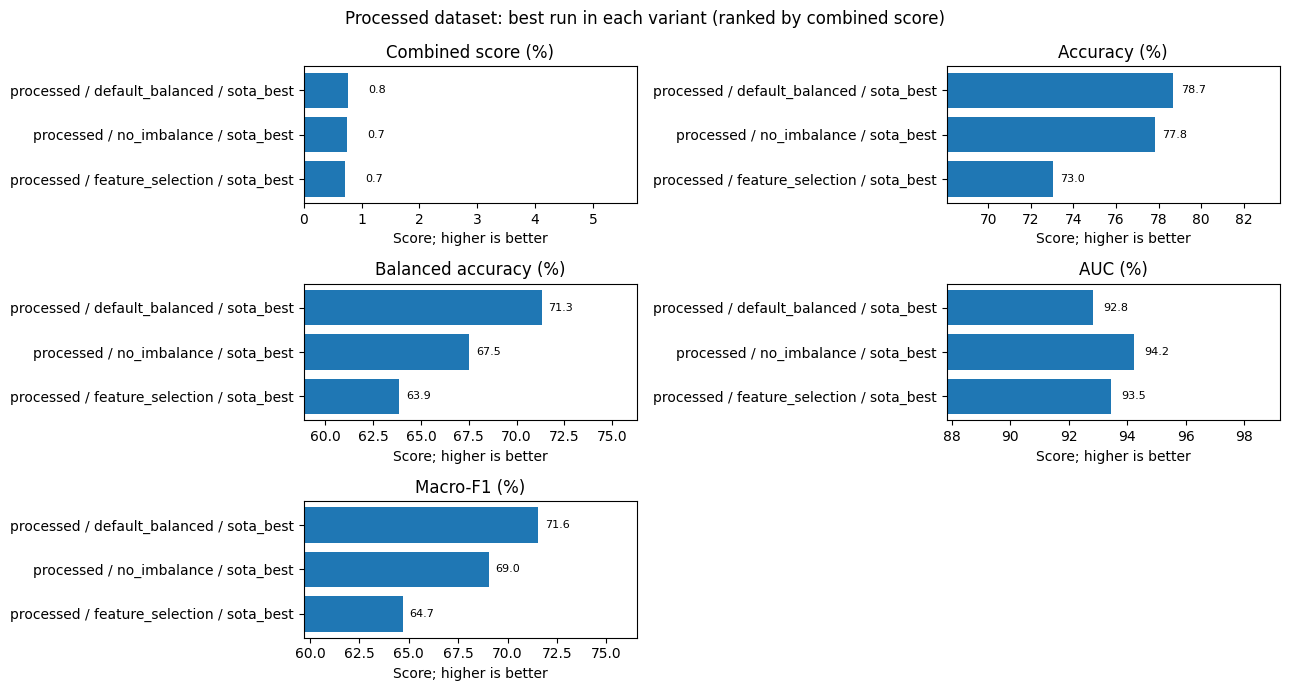

saved /home/zeus/content/IOT_fusion/Results_Figures/compare_processed_best_metrics.png


,dataset_source,variant,experiment_name,image_model,tabular_model,mode,scope,epochs,batch_size,feature_count,...,test_loss,test_acc,test_bacc,test_auc,test_f1_macro,checkpoint_path,onnx_path,expert_names,loss_score,combined_score
0,processed,default_balanced,sota_best,sota,multi_expert,late_fusion,sota,7,48,87,...,0.852509,78.695652,71.308654,0.928205,0.715513,/home/zeus/content/IOT_fusion/outputs/ablation...,/home/zeus/content/IOT_fusion/ONNX_Bests/proce...,cvt_img_only|mlp_tab_only|cnn_mlp_intermediate...,0.458251,0.762361
2,processed,no_imbalance,sota_best,sota,multi_expert,late_fusion,sota,22,64,87,...,0.731031,77.826087,67.534577,0.942155,0.690323,/home/zeus/content/IOT_fusion/outputs/ablation...,/home/zeus/content/IOT_fusion/ONNX_Bests/proce...,cnn_img_only|tabtransformer_tab_only|cnn_tabtr...,0.453083,0.746468
1,processed,feature_selection,sota_best,sota,multi_expert,late_fusion,sota,14,64,32,...,0.942540,73.043478,63.864423,0.934546,0.646804,/home/zeus/content/IOT_fusion/outputs/ablation...,/home/zeus/content/IOT_fusion/ONNX_Bests/proce...,cnn_img_only|tabtransformer_tab_only|cnn_tabtr...,0.444398,0.714942


In [1]:

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "Results_Logs" / "ablation_summary.csv").exists():
    ROOT = ROOT.parent
summary = pd.read_csv(ROOT / "Results_Logs" / "ablation_summary.csv")
metric_cols = ["test_acc", "test_bacc", "test_auc", "test_f1_macro"]
metric_labels = {
    "test_acc": "Accuracy (%)",
    "test_bacc": "Balanced accuracy (%)",
    "test_auc": "AUC (%)",
    "test_f1_macro": "Macro-F1 (%)",
    "combined_score": "Combined score (%)",
}
summary["combined_score"] = (
    0.35 * summary["test_f1_macro"].astype(float)
    + 0.25 * (summary["test_bacc"].astype(float) / 100.0)
    + 0.25 * summary["test_auc"].astype(float)
    + 0.10 * (summary["test_acc"].astype(float) / 100.0)
    + 0.05
    * (
        1.0
        / (
            1.0
            + summary["final_val_loss"].astype(float)
            + (summary["final_val_loss"].astype(float) - summary["final_train_loss"].astype(float)).abs()
        )
    )
)

def best_per_track(df):
    # Return one winner per dataset source and variant for compact comparisons.
    return (
        df.sort_values(["combined_score", "test_f1_macro", "test_bacc", "test_auc", "test_acc"], ascending=[False, False, False, False, False])
        .groupby(["dataset_source", "variant"], as_index=False)
        .head(1)
        .sort_values(["dataset_source", "variant"])
        .reset_index(drop=True)
    )

def metric_to_percent(series, metric):
    values = series.astype(float).copy()
    if metric in {"test_auc", "test_f1_macro"}:
        values = values * 100.0
    return values

def plot_metric_bars(df, title, out_name):
    data = df.sort_values("combined_score", ascending=False).copy()
    labels = data["dataset_source"] + " / " + data["variant"] + " / " + data["experiment_name"]
    fig_h = max(4.8, 0.72 * len(data) + 2.0)
    fig, axes = plt.subplots(3, 2, figsize=(13, max(fig_h, 7.0)))
    for ax, metric in zip(axes.ravel(), ["combined_score", *metric_cols]):
        values = metric_to_percent(data[metric], metric)
        ax.barh(labels, values)
        ax.invert_yaxis()
        ax.set_title(metric_labels[metric])
        ax.set_xlabel("Score; higher is better")
        ax.set_xlim(max(0, values.min() - 5), min(100, values.max() + 5))
        for y, value in enumerate(values):
            ax.text(value + 0.35, y, f"{value:.1f}", va="center", fontsize=8)
    axes.ravel()[-1].axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    out = ROOT / "Results_Figures" / out_name
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=160)
    plt.show()
    print(f"saved {out}")

df = summary[summary["dataset_source"] == "processed"].copy()
ranked = best_per_track(df)
display(ranked[["variant", "experiment_name", "mode", "image_model", "tabular_model", "combined_score", *metric_cols, "onnx_path"]])
plot_metric_bars(ranked, "Processed dataset: best run in each variant (ranked by combined score)", "compare_processed_best_metrics.png")

display(ranked.sort_values("combined_score", ascending=False))
